# Generalisation Under Attack-Family Shift in Syscall Intrusion Detection

Operational intrusion detection is not evaluated by performance on previously observed attack templates, but by its capacity to maintain reliability when the threat landscape changes. The present study therefore examines how detection quality behaves under family-level variation, where malicious behaviours may preserve their intent while changing their concrete syscall manifestation.

The central question is whether the learned decision rule captures robust behavioural irregularities or mainly relies on family-specific patterns seen during model development. This distinction is essential for deployment, because signature-like behaviour can produce convincing validation metrics while failing on genuinely novel attacks.

The analysis combines family-level recall, scenario-level error concentration, sequence-length sensitivity, and perturbation stability. Together, these views provide a coherent description of model robustness beyond aggregate metrics.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils import RESULTS_ROOT, ensure_dir

sns.set_theme(style='whitegrid', context='talk')

tables_dir = RESULTS_ROOT / 'tables'
fig_dir = ensure_dir(PROJECT_ROOT / 'reports' / 'figures')

family_err = pd.read_csv(tables_dir / 'error_analysis_by_attack_family.csv')
scenario_err = pd.read_csv(tables_dir / 'error_analysis_by_attack_scenario.csv')
len_err = pd.read_csv(tables_dir / 'error_analysis_by_length_bin.csv')
hard_attacks = pd.read_csv(tables_dir / 'error_analysis_hardest_attacks.csv')
robust_df = pd.read_csv(tables_dir / 'robustness_stability_lstm.csv')
stability_sum = pd.read_csv(tables_dir / 'robustness_prediction_stability_summary.csv')
lstm_best = pd.read_csv(tables_dir / 'lstm_best_run_summary.csv')
baseline_test = pd.read_csv(tables_dir / 'baseline_results_test_ranked.csv')

print('Loaded all required artefacts for variation analysis.')
print('Families:', sorted(family_err['attack_family'].dropna().unique()))
print('Models:', sorted(family_err['model'].dropna().unique()))

Loaded all required artefacts for variation analysis.
Families: ['Adduser', 'Hydra_FTP', 'Hydra_SSH', 'Java_Meterpreter', 'Meterpreter', 'Web_Shell']
Models: ['lstm_post_e128_h128_d0.1', 'rf_tfidf']


## Family-Specific Detection Capacity

Aggregate F1 scores can mask clinically important blind spots. For security applications, the relevant unit of risk is often the attack family itself, since operational procedures and remediation actions differ across intrusion mechanisms. The following comparison therefore focuses on recall by family for the strongest Random Forest baseline and the selected bidirectional LSTM configuration.

This perspective clarifies whether performance gains arise from broad behavioural understanding or from better handling of only a subset of attack types.

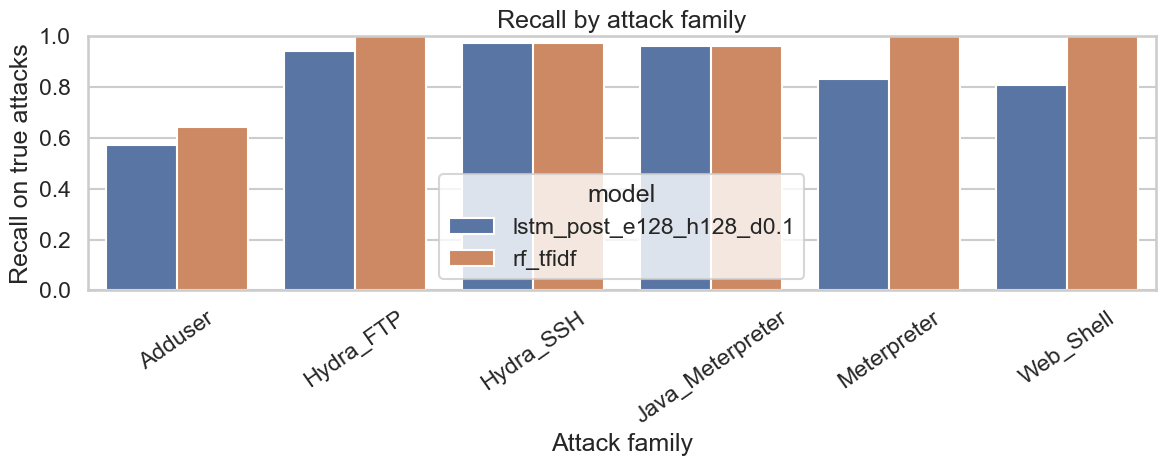

,model,attack_family,recall_attack_family,count
0,lstm_post_e128_h128_d0.1,Adduser,0.571429,28.0
6,rf_tfidf,Adduser,0.642857,28.0
3,lstm_post_e128_h128_d0.1,Hydra_FTP,0.942857,35.0
9,rf_tfidf,Hydra_FTP,1.000000,35.0
5,lstm_post_e128_h128_d0.1,Hydra_SSH,0.973684,38.0
8,rf_tfidf,Hydra_SSH,0.973684,38.0
4,lstm_post_e128_h128_d0.1,Java_Meterpreter,0.961538,26.0
7,rf_tfidf,Java_Meterpreter,0.961538,26.0
2,lstm_post_e128_h128_d0.1,Meterpreter,0.833333,12.0
10,rf_tfidf,Meterpreter,1.000000,12.0


In [ ]:
best_baseline_name = baseline_test.sort_values('f1', ascending=False).iloc[0]['model']
if 'model' in lstm_best.columns:
    best_lstm_name = lstm_best.iloc[0]['model']
else:
    best_lstm_name = lstm_best.iloc[0]['run_name']

plot_df = hard_attacks[hard_attacks['model'].isin([best_baseline_name, best_lstm_name])].copy()
plot_df = plot_df.sort_values(['attack_family', 'model'])

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=plot_df, x='attack_family', y='recall_attack_family', hue='model', ax=ax)
ax.set_title('Recall by attack family')
ax.set_xlabel('Attack family')
ax.set_ylabel('Recall on true attacks')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=35)
fig.tight_layout()
fig.savefig(fig_dir / 'attack_variation_recall_by_family.png', dpi=150)
plt.show()
plt.close(fig)

display(plot_df)

## Reading the Family-Level Pattern

The resulting profile shows that model quality is not uniform across families. Adduser remains the principal weak point, which is consistent with its behavioural ambiguity: many of its syscall sequences are close to legitimate administrative actions. In contrast, families with sharper statistical footprints are detected more consistently by frequency-based models.

Where differences appear between the LSTM and Random Forest, they should be interpreted as representational bias rather than global superiority. The Random Forest leverages stable frequency signatures, whereas the LSTM can improve decision balance at selected operating points but remains sensitive to conservative thresholding on subtle families.

## Scenario Concentration of Errors

A scenario-wise decomposition is necessary to distinguish random variance from structured generalisation failure. When errors cluster in specific scenarios, the model is likely reacting to contextual shift in execution traces rather than failing uniformly. This analysis therefore evaluates whether degradation is diffuse or concentrated in identifiable operational contexts.

Such concentration has direct practical implications: it motivates scenario-aware monitoring and threshold governance instead of relying on a single global operating point.

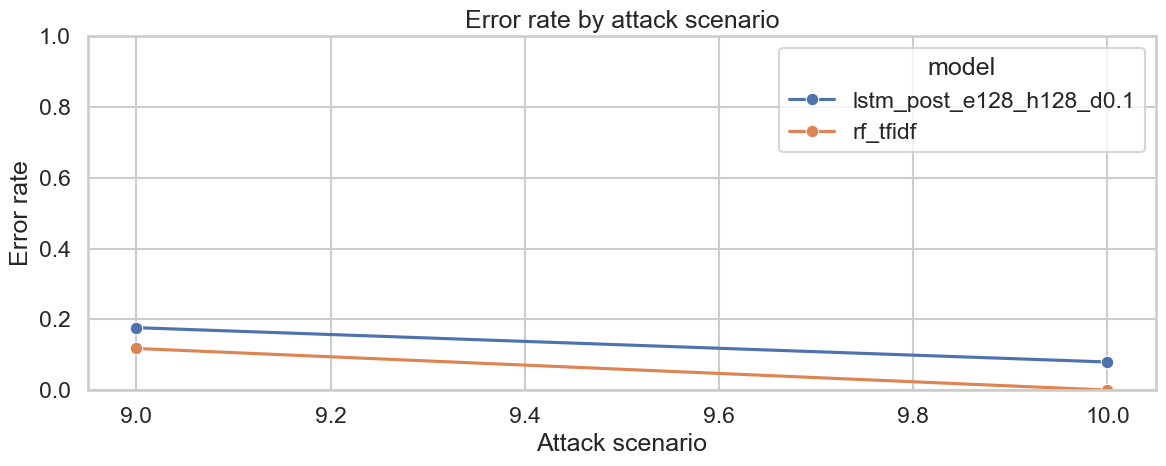

,model,attack_scenario,count,error_rate,fpr,fnr
0,lstm_post_e128_h128_d0.1,9.0,102.0,0.176471,0.0,0.176471
2,rf_tfidf,9.0,102.0,0.117647,0.0,0.117647
1,lstm_post_e128_h128_d0.1,10.0,63.0,0.079365,0.0,0.079365
3,rf_tfidf,10.0,63.0,0.000000,0.0,0.000000


In [ ]:
plot_scen = scenario_err[scenario_err['model'].isin([best_baseline_name, best_lstm_name])].copy()
plot_scen = plot_scen.sort_values(['attack_scenario', 'model'])

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=plot_scen, x='attack_scenario', y='error_rate', hue='model', marker='o', ax=ax)
ax.set_title('Error rate by attack scenario')
ax.set_xlabel('Attack scenario')
ax.set_ylabel('Error rate')
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(fig_dir / 'attack_variation_error_by_scenario.png', dpi=150)
plt.show()
plt.close(fig)

display(plot_scen)

## Interpreting Scenario Shift

The error curves indicate that distribution shift is structured and not anecdotal. This is compatible with the previously observed gap between validation and test behaviour, where unseen scenarios alter the joint distribution of normal and malicious traces. In this setting, a model that appears stable on a single validation scenario can still experience measurable degradation on unseen contexts.

From a deployment standpoint, this supports periodic recalibration and drift surveillance at the scenario level, especially when the operating environment evolves.

## Sensitivity to Sequence Length Regimes

Trace length is not a neutral property in syscall modelling. Very short traces may contain insufficient behavioural evidence, whereas very long traces can dilute malicious signal within routine activity. Examining error rates across length bins therefore reveals whether the representation remains informative across heterogeneous temporal contexts.

This lens also evaluates the practical adequacy of the preprocessing policy based on percentile truncation and dual-view encoding.

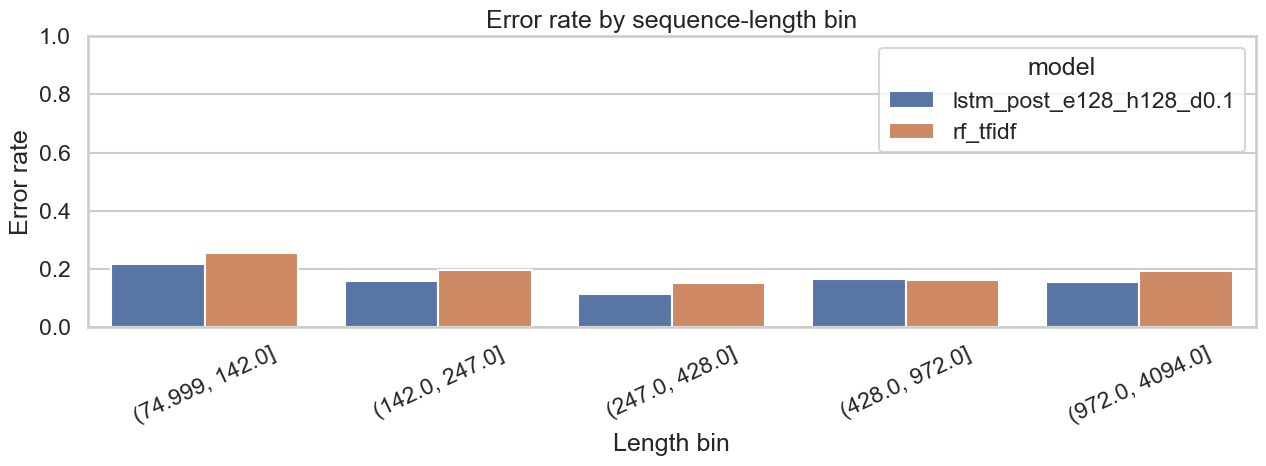

,model,length_bin,count,error_rate,mean_length
0,lstm_post_e128_h128_d0.1,"(74.999, 142.0]",258.0,0.217054,113.996124
1,lstm_post_e128_h128_d0.1,"(142.0, 247.0]",257.0,0.159533,189.369650
2,lstm_post_e128_h128_d0.1,"(247.0, 428.0]",258.0,0.112403,327.782946
3,lstm_post_e128_h128_d0.1,"(428.0, 972.0]",256.0,0.164062,644.535156
4,lstm_post_e128_h128_d0.1,"(972.0, 4094.0]",257.0,0.155642,1785.093385
5,rf_tfidf,"(74.999, 142.0]",258.0,0.255814,113.996124
6,rf_tfidf,"(142.0, 247.0]",257.0,0.194553,189.369650
7,rf_tfidf,"(247.0, 428.0]",258.0,0.151163,327.782946
8,rf_tfidf,"(428.0, 972.0]",256.0,0.160156,644.535156
9,rf_tfidf,"(972.0, 4094.0]",257.0,0.190661,1785.093385


In [ ]:
plot_len = len_err[len_err['model'].isin([best_baseline_name, best_lstm_name])].copy()

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=plot_len, x='length_bin', y='error_rate', hue='model', ax=ax)
ax.set_title('Error rate by sequence-length bin')
ax.set_xlabel('Length bin')
ax.set_ylabel('Error rate')
ax.tick_params(axis='x', rotation=25)
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(fig_dir / 'attack_variation_error_by_length.png', dpi=150)
plt.show()
plt.close(fig)

display(plot_len)

## Interpreting Length-Dependent Error Behaviour

The observed profile confirms that error is length-dependent rather than random. Short sequences typically increase uncertainty because discriminative temporal context is limited. Longer sequences can be advantageous for recurrent models, but only when the attack signal is not obscured by dominant benign subsequences.

These dynamics explain why sequence modelling can offer selective gains without yielding universal dominance across all evaluation metrics.

## Behavioural Stability Under Controlled Perturbations

Robust detectors should not reverse their decisions under mild, non-semantic corruption of input traces. The following experiment evaluates this property through local deletion and token substitution, then measures both metric degradation and prediction-level stability.

The objective is not to emulate fully adaptive adversaries, but to test whether the learned representation is brittle under realistic noise introduced by collection artifacts or incomplete traces.

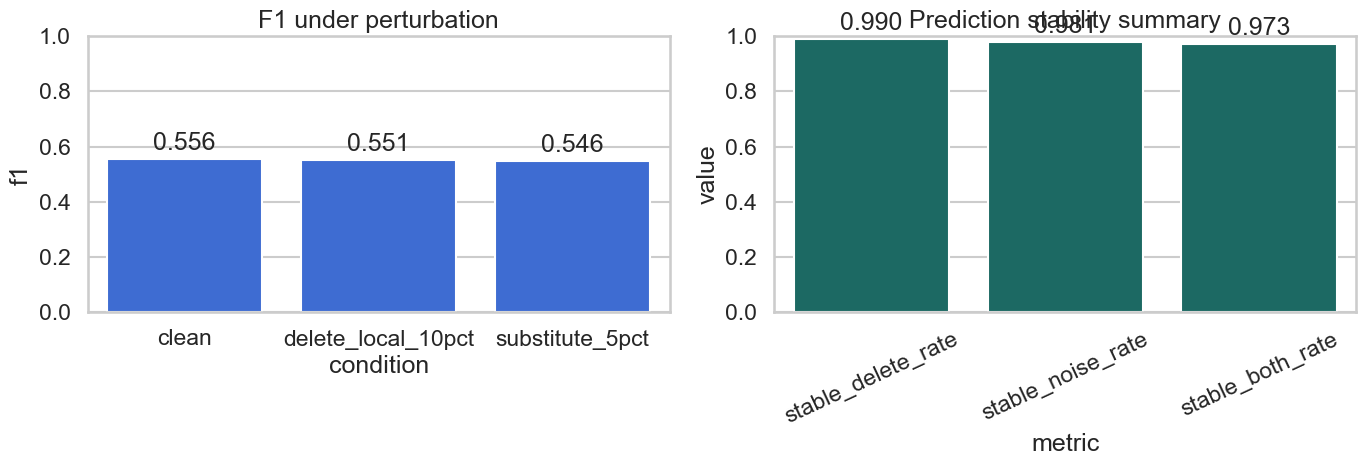

,condition,accuracy,precision,recall,f1,fpr,fnr,tp,tn,fp,fn,roc_auc,pr_auc,delta_f1_vs_clean,delta_auc_vs_clean
0,clean,0.812597,0.399471,0.915152,0.556169,0.202498,0.084848,151.0,894.0,227.0,14.0,0.889822,0.454867,0.000000,0.000000
1,delete_local_10pct,0.808709,0.394256,0.915152,0.551095,0.206958,0.084848,151.0,889.0,232.0,14.0,0.887208,0.450088,-0.005075,-0.002614
2,substitute_5pct,0.810264,0.394102,0.890909,0.546468,0.201606,0.109091,147.0,895.0,226.0,18.0,0.885416,0.444211,-0.009701,-0.004406


,metric,value
0,stable_delete_rate,0.989891
1,stable_noise_rate,0.980560
2,stable_both_rate,0.972784


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=robust_df, x='condition', y='f1', ax=axes[0], color='#2563eb')
axes[0].set_title('F1 under perturbation')
axes[0].set_ylim(0, 1)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.3f', padding=3)

sns.barplot(data=stability_sum, x='metric', y='value', ax=axes[1], color='#0f766e')
axes[1].set_title('Prediction stability summary')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=25)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.3f', padding=3)

fig.tight_layout()
fig.savefig(fig_dir / 'attack_variation_robustness.png', dpi=150)
plt.show()
plt.close(fig)

display(robust_df)
display(stability_sum)

## Interpreting Robustness Evidence

The small metric deltas and high prediction-stability rates indicate that the recurrent representation is not excessively dependent on isolated token positions. In practical terms, this behaviour is desirable because system traces collected in production may be partially noisy or incomplete.

At the same time, these perturbations remain non-adaptive. They do not exhaust the space of adversarial manipulation strategies, especially mimicry patterns designed to preserve malicious intent while shifting observable syscall statistics. Robustness conclusions should therefore be considered strong for random corruption, but provisional for intelligent evasion.

## Synthesis and Scientific Implications

Across the full experimental pipeline, three conclusions emerge with high consistency. First, strict protocol control and leakage prevention are indispensable; without them, apparent gains are methodologically unreliable. Second, frequency-based representations capture a substantial portion of the discriminative structure in ADFA-LD, which explains the persistent strength of Random Forest baselines on ranking metrics. Third, sequential modelling contributes targeted advantages at operational decision points by reducing false-alarm pressure and maintaining strong stability under moderate perturbation.

The principal limitation is shared by both modelling families: attacks whose syscall-number patterns overlap legitimate administration remain difficult to separate. This indicates that further progress is unlikely to come from architecture changes alone. The most promising direction is richer event semantics, including syscall arguments and execution context, combined with calibrated threshold policies tailored to deployment risk profiles.

In consequence, the evidence supports a pragmatic strategy: maintain strong frequency-based baselines as reference systems, use sequential models where operating-point control is critical, and prioritise representation enrichment to address the remaining hard failure modes.